# ETF SAA-CVaR, RS-CVaR, DR-CVaR, and RSDR-CVaR

This notebook uses ETF returns as the **tradable portfolio universe** and regime outputs as the **regime-conditioning layer**.

The important separation is:

- ETF returns are what the optimizer allocates into.
- Regime states and regime probabilities are not traded directly; they change how the historical ETF return scenarios are weighted.

The notebook computes:

1. **SAA-CVaR**: empirical CVaR using historical ETF returns only.
2. **DR-CVaR**: Wasserstein distributionally robust CVaR using the full historical ETF return window.
3. **RS-CVaR**: regime-switching CVaR, where predicted next-regime probabilities weight regime-specific historical ETF losses, without Wasserstein robustness.
4. **RSDR-CVaR**: regime-switching distributionally robust CVaR, which combines regime-weighted historical losses with Wasserstein robustness.

It then writes monthly returns, weights, optimizer diagnostics, and performance metrics to:

```python
outputs/CVaR/etf_cvar_gamma_tuning/
```


## End-to-end process used in this notebook

This notebook is a monthly ETF portfolio backtest. The regime model is used as an information layer, while the ETF returns are the tradable assets. At every rebalance month, the optimizer chooses ETF allocation weights \(x\).

Concrete run used here:

- Tradable ETFs: SPY, XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY.
- Number of tradable ETFs: \(I=10\).
- ETF return frequency: monthly.
- Raw ETF return file: January 2000 to December 2022.
- Backtest after ETF/regime alignment and start-date filter: January 2004 to December 2022.
- Formation/training window: 120 months.
- CVaR prediction/holding window: 1 month.
- First formation window: January 2004 to December 2013.
- First out-of-sample prediction month: January 2014.

---

## 1. Inputs loaded

The notebook loads monthly ETF returns:

$$
R_t =
\begin{bmatrix}
R_{t,1}\\
R_{t,2}\\
\vdots\\
R_{t,I}
\end{bmatrix}
\in \mathbb{R}^{I}
$$

where \(I\) is the number of tradable ETFs. One row is one month of ETF returns across all ETFs.

It also loads regime information from the regime-output files:

- hard regime labels;
- filtered regime probabilities;
- the regime transition matrix.

The important separation is:

$$
\text{ETF returns} \rightarrow \text{portfolio allocation}
$$

while:

$$
\text{regime probabilities} \rightarrow \text{scenario reweighting}
$$

The regime states are not traded directly. They change how much probability mass the optimizer places on different historical ETF return scenarios.

---

## 2. Rolling monthly training window

At each rebalance month \(t\), the notebook looks back at the previous 120 monthly ETF return vectors:

$$
\mathcal{R}_t
=
\{R_{t-120}, R_{t-119},\ldots,R_{t-1}\}.
$$

The portfolio is solved using only this historical training window. The next month \(R_t\) is kept out-of-sample and is used only to measure realized performance after the weights are chosen.

So the rolling logic is:

$$
\text{past 120 months}
\rightarrow
\text{choose ETF weights } x_t
\rightarrow
\text{apply to next month } R_t.
$$

The notebook then moves forward by one month and repeats the process.

---

## 3. SAA-CVaR baseline

SAA-CVaR uses equal probability on every historical training scenario:

$$
\widehat{\mathbb{P}}_e
=
\frac{1}{N}
\sum_{n=1}^{N}\delta_{R_n}.
$$

The optimization problem is:

$$
\min_{x\in\mathcal{W},\,v\in\mathbb{R}}
\left\{
v+
\frac{1}{N(1-\eta)}
\sum_{n=1}^{N}
\left[\ell(x,R_n)-v\right]_+
\right\},
$$

where:

$$
\ell(x,R_n)=-x^\top R_n.
$$

SAA-CVaR asks: using only the historical sample, which ETF allocation minimizes the average loss beyond the 95% VaR threshold?

---

## 4. Regime probability feed for RS-CVaR and RSDR-CVaR

For regime-aware methods, the notebook first gets the previous month's filtered regime probability vector:

$$
\pi_{t-1}.
$$

It then multiplies that vector by the regime transition matrix:

$$
w_t
=
\pi_{t-1}A.
$$

Here:

- \(\pi_{t-1}\) is the probability of the current regime, estimated from data up to the previous month;
- \(A\) is the transition matrix;
- \(w_t\) is the predicted probability of each regime for the next investment month.

These regime weights are then mapped back onto the 120 historical ETF scenarios. If regime \(k\) has \(N_k\) observations in the training window, then each observation in that regime receives:

$$
p_n
=
\frac{w_{t,k}}{N_k},
\qquad
\text{for } s_n=k.
$$

This is how regime prediction enters the CVaR optimizer: it changes the scenario probabilities, not the ETF universe.

---

## 5. DR-CVaR and the Wasserstein robustness parameter

DR-CVaR keeps the full historical training window but does not fully trust the empirical distribution. It considers nearby plausible distributions:

$$
\mathcal{U}^{W}(\theta)
=
\left\{
\mathbb{P}\in\mathcal{P}(\mathbb{R}^{I})
:
W_m(\mathbb{P},\widehat{\mathbb{P}}_e)\leq\theta
\right\}.
$$

The high-level DR-CVaR problem is:

$$
\min_{x,v}
\left\{
v+
\frac{1}{1-\eta}
\sup_{\mathbb{P}\in\mathcal{U}^{W}(\theta)}
\mathbb{E}^{\mathbb{P}}
\left[
\left[\ell(x,R)-v\right]_+
\right]
\right\}.
$$

In this notebook, the Wasserstein radius is controlled by:

$$
\theta_{\mathrm{DR}}
=
\gamma N^{-1/I}.
$$

With the default \(\ell_1\) ground norm, the equivalent robust penalty is:

$$
\frac{\theta_{\mathrm{DR}}}{1-\eta}\|x\|_\infty.
$$

So increasing \(\gamma\) increases robustness, but if it is too large, the optimizer can become overly conservative and move toward equal-weight allocations.

---

## 6. RSDR-CVaR combines regime weighting and Wasserstein robustness

RSDR-CVaR uses both ideas:

1. regime probabilities reweight historical scenarios;
2. Wasserstein robustness stress-tests the regime-weighted tail loss.

The high-level objective is:

$$
\min_{x,v}
\left\{
v+
\frac{1}{1-\eta}
\sum_{k=1}^{K}
w_{t,k}
\sup_{\mathbb{P}_k\in\mathcal{U}^{W}_{k}(\theta_k)}
\mathbb{E}^{\mathbb{P}_k}
\left[
\left[\ell(x,R)-v\right]_+
\right]
\right\}.
$$

The notebook implements this as regime-weighted empirical CVaR plus a regime-weighted Wasserstein robust penalty.

The effective RSDR radius is computed from the regimes present in the rolling training window:

$$
\theta_{\mathrm{RSDR},t}
=
\frac{
\sum_{k=1}^{K} w_{t,k}\,\theta_k
}{
\sum_{k=1}^{K} w_{t,k}
},
\qquad
\theta_k=\gamma N_k^{-1/I}.
$$

So the RSDR optimizer is answering:

> Given the predicted next-regime mix, which ETF allocation minimizes tail loss after allowing each relevant regime distribution to move to a nearby worse distribution?
\n

## Core formulas used, with intuition

This section shows the evolution from plain empirical CVaR to regime-switching distributionally robust CVaR.

The important idea is:

> The optimizer always chooses ETF weights \(x\), but each method changes how historical ETF return scenarios are trusted, weighted, or stress-tested.

---

## 1. Return scenario and portfolio loss

This notebook uses a **fixed 120-month formation window** at every rebalance.

Concrete setup used here:

- Tradable ETF universe: \(I=10\) ETFs.
- Assets: `SPY`, `XLB`, `XLE`, `XLF`, `XLI`, `XLK`, `XLP`, `XLU`, `XLV`, `XLY`.
- Raw ETF monthly return file: January 2000 to December 2022.
- After aligning with available regime labels and matching the altdata deep-dive start date: January 2004 to December 2022.
- Formation/training window: previous 120 months.
- CVaR prediction/holding window: the next 1 month.
- First formation window: January 2004 to December 2013.
- First out-of-sample prediction month: January 2014.
- Last out-of-sample prediction month: December 2022.

So \(n\) is **not an unspecified calendar month**. It is the row index inside the current 120-month formation window:

$$
n=1,2,\ldots,120.
$$

For rebalance month \(t\), the formation window is:

$$
\mathcal{F}_t
=
\{R_{t-120},R_{t-119},\ldots,R_{t-1}\}.
$$

For the first rebalance in this notebook:

$$
\mathcal{F}_{\mathrm{Jun\ 2013}}
=
\{R_{\mathrm{Jun\ 2003}},R_{\mathrm{Jul\ 2003}},\ldots,R_{\mathrm{May\ 2013}}\}.
$$

The optimizer chooses ETF weights using this formation window, then applies those weights to the next month:

$$
R_{\mathrm{Jan\ 2014}}.
$$

That next month is the out-of-sample CVaR/backtest observation. The process then rolls forward by one month.

---

## One return scenario

Inside any given formation window, one historical scenario is one monthly ETF return vector:

$$
R_n \in \mathbb{R}^{10}.
$$

For example:

$$
R_n
=
\begin{bmatrix}
R_{n,\mathrm{SPY}}\\
R_{n,\mathrm{XLB}}\\
R_{n,\mathrm{XLE}}\\
\vdots\\
R_{n,\mathrm{XLY}}
\end{bmatrix}.
$$

Each entry is the return of one ETF in the same month. For example, \(R_{\mathrm{Jun\ 2008}}\) is one row containing the June 2008 returns of all 10 ETFs.

The portfolio weight vector is:

$$
x
=
\begin{bmatrix}
x_{\mathrm{SPY}}\\
x_{\mathrm{XLB}}\\
x_{\mathrm{XLE}}\\
\vdots\\
x_{\mathrm{XLY}}
\end{bmatrix},
\qquad
\sum_{i=1}^{10}x_i=1,\quad x_i\geq 0.
$$

The portfolio return in historical scenario \(n\) is:

$$
x^\top R_n.
$$

Because CVaR is written as a loss minimization problem, the portfolio loss is:

$$
\ell(x,R_n)=-x^\top R_n.
$$

### Intuition

Each row of the 120-month formation window becomes one possible portfolio loss scenario after we choose ETF weights \(x\). The optimizer is not predicting each ETF separately. It is choosing one 10-ETF allocation and testing that allocation against the 120 historical monthly return vectors.

---

## 2. Empirical historical distribution

The empirical historical distribution is:

$$
\widehat{\mathbb{P}}_{e}
=
\frac{1}{N}\sum_{n=1}^{N}\delta_{R_n}.
$$

Here:

- \(N=120\) is the number of historical monthly scenarios in each rolling formation window.
- \(R_n\) is one monthly ETF return vector from that 120-month formation window.
- \(\delta_{R_n}\) is a Dirac point mass at \(R_n\).
- \(\frac{1}{N}\) means each historical scenario receives equal probability.

### Intuition

This is the baseline historical view:

> "The future return distribution is represented by the past \(N\) ETF return scenarios, and each past scenario is equally likely."

This is the distribution used by SAA-CVaR before robustness or regime conditioning is added.

---

## 3. SAA-CVaR

SAA-CVaR uses the empirical distribution directly:

$$
\min_{x\in\mathcal{W},\,v\in\mathbb{R}}
\left\{
v+
\frac{1}{N(1-\eta)}
\sum_{n=1}^{N}
\left[\ell(x,R_n)-v\right]_{+}
\right\}.
$$

Here:

- \(x\) is the ETF allocation.
- \(v\) is the VaR threshold variable.
- \(\eta\) is the confidence level, usually \(0.95\).
- \([\ell(x,R_n)-v]_+\) keeps only the part of the loss that exceeds the VaR threshold.

### Intuition

SAA-CVaR asks:

> "Using only the historical sample, which ETF allocation minimizes the average loss beyond the 95% VaR threshold?"

It is simple and transparent, but it fully trusts the historical sample. If the past sample under-represents crisis losses, SAA-CVaR can be too optimistic.

---

## 4. DR-CVaR

The Wasserstein ambiguity set is:

$$
\mathcal{U}^{W}(\theta)
=
\left\{
\mathbb{P}\in\mathcal{P}(\mathbb{R}^{I})
:
W_m\!\left(\mathbb{P},\widehat{\mathbb{P}}_{e}\right)
\leq \theta
\right\}.
$$

This means:

> Consider all distributions \(\mathbb{P}\) that are within Wasserstein distance \(\theta\) from the empirical distribution \(\widehat{\mathbb{P}}_e\).

The DR-CVaR objective is:

$$
\min_{x\in\mathcal{W},\,v\in\mathbb{R}}
\left\{
v+
\frac{1}{1-\eta}
\sup_{\mathbb{P}\in\mathcal{U}^{W}(\theta)}
\mathbb{E}^{\mathbb{P}}
\left[
\left[\ell(x,R)-v\right]_{+}
\right]
\right\}.
$$

### Intuition of the high-level formula

The inner supremum is the key:

$$
\sup_{\mathbb{P}\in\mathcal{U}^{W}(\theta)}
$$

It asks:

> "Among all plausible distributions close to the historical distribution, which one makes tail loss worst?"

So DR-CVaR does not only optimize against the observed historical sample. It optimizes against a pessimistic distribution near the historical sample.

### Explicit penalty form used by the notebook

The high-level worst-case search is implemented through a dual-norm robust penalty. For the default \(\ell_1\) Wasserstein ground norm, the dual norm is \(\ell_\infty\), so the implemented objective becomes:

$$
\min_{x,v}
\left\{
v+
\frac{1}{1-\eta}
\sum_{n=1}^{N}
\frac{1}{N}
\left[\ell(x,R_n)-v\right]_+
+
\frac{\theta_{\mathrm{DR}}}{1-\eta}\|x\|_{\infty}
\right\}.
$$

where:

$$
\theta_{\mathrm{DR}}=\gamma N^{-1/I}.
$$

### Intuition of the penalty

The penalty

$$
\frac{\theta_{\mathrm{DR}}}{1-\eta}\|x\|_{\infty}
$$

punishes large single-ETF concentration. A larger \(\theta\) means the optimizer is allowed to imagine more severe nearby distributions, so it becomes more conservative.

If \(\theta\) is too large, the optimizer may move toward equal weight because equal weight minimizes the largest single ETF allocation.

---

## 5. RS-CVaR

For regime-switching CVaR, the historical scenarios are split by regime. The empirical distribution inside regime \(k\) is:

$$
\widehat{\mathbb{P}}_{k}
=
\frac{1}{N_k}
\sum_{n:s_n=k}
\delta_{R_n}.
$$

Here:

- \(s_n\) is the regime label for scenario \(n\).
- \(N_k\) is the number of historical scenarios in regime \(k\).
- \(\widehat{\mathbb{P}}_k\) is the regime-specific empirical distribution.

The predicted next-regime weight is:

$$
w_t=\pi_{t-1}A_t.
$$

where:

- \(\pi_{t-1}\) is the previous month's filtered regime probability vector.
- \(A_t\) is the transition matrix estimated from the rolling state history.
- \(w_{t,k}\) is the predicted probability of regime \(k\) for the next investment month.

The RS-CVaR objective is:

$$
\min_{x\in\mathcal{W},\,v\in\mathbb{R}}
\left\{
v+
\frac{1}{1-\eta}
\sum_{k=1}^{K}
w_{t,k}
\,
\mathbb{E}^{\widehat{\mathbb{P}}_{k}}
\left[
\left[\ell(x,R)-v\right]_{+}
\right]
\right\}.
$$

### Intuition

RS-CVaR asks:

> "If the regime model says next month is more likely to look like regime \(k\), then historical months from regime \(k\) should matter more in the CVaR calculation."

So RS-CVaR does not treat every historical month equally. It uses regime probabilities to reshape the historical scenario distribution.

However, RS-CVaR still trusts the regime-specific historical samples. It does not yet stress-test the distribution using a Wasserstein ball.

---

## 6. RSDR-CVaR

RSDR-CVaR combines regime switching and distributional robustness.

Each regime has its own Wasserstein ambiguity set:

$$
\mathcal{U}^{W}_{k}(\theta_k)
=
\left\{
\mathbb{P}_k:
W_m\!\left(\mathbb{P}_k,\widehat{\mathbb{P}}_{k}\right)
\leq \theta_k
\right\}.
$$

A return-level representation of the regime-switching ambiguity set is:

$$
\mathcal{U}^{RS}_{t}(\theta)
=
\left\{
\mathbb{P}
=
\sum_{k=1}^{K}w_{t,k}\mathbb{P}_{k}
:
W_m\!\left(\mathbb{P}_{k},\widehat{\mathbb{P}}_{k}\right)
\leq \theta_k,\ \forall k
\right\}.
$$

The high-level RSDR-CVaR objective is:

$$
\min_{x\in\mathcal{W},\,v\in\mathbb{R}}
\left\{
v+
\frac{1}{1-\eta}
\sum_{k=1}^{K}
w_{t,k}
\sup_{\mathbb{P}_k\in\mathcal{U}^{W}_{k}(\theta_k)}
\mathbb{E}^{\mathbb{P}_k}
\left[
\left[\ell(x,R)-v\right]_{+}
\right]
\right\}.
$$

### Intuition of the high-level formula

RSDR-CVaR asks two questions at the same time:

1. **Regime switching:** Which regimes are likely next?
2. **Distributional robustness:** Within those likely regimes, what nearby distribution would make tail loss worse?

So the method says:

> "Focus on the regimes that are likely next, but do not overtrust the historical observations inside those regimes."

### Explicit penalty form used by the notebook

The notebook implements RSDR-CVaR as:

$$
\min_{x,v}
\left\{
v+
\frac{1}{1-\eta}
\sum_{k=1}^{K}
w_{t,k}
\frac{1}{N_k}
\sum_{n:s_n=k}
\left[\ell(x,R_n)-v\right]_+
+
\frac{\theta_{\mathrm{RSDR},t}}{1-\eta}\|x\|_{\infty}
\right\}.
$$

The regime-aware radius is:

$$
\theta_{\mathrm{RSDR},t}
=
\sum_{k=1}^{K}
w_{t,k}\theta_k,
\qquad
\theta_k=\gamma N_k^{-1/I}.
$$

### Intuition of the penalty

The first term after \(v\) is the **regime-weighted empirical tail loss**. The final term is the **Wasserstein robustness penalty**.

So RSDR-CVaR is:

$$
\text{RS-CVaR tail loss}
+
\text{Wasserstein robustness penalty}.
$$

This is why RSDR can outperform when the regime signal is useful and the robustness penalty is not too large. If the penalty becomes too large, the optimizer can ignore the regime signal and move toward equal-weight.


In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import linprog, minimize

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------
def find_project_dir(start=None):
    """Find the project root that contains Data/etf_returns.csv.

    Recommended use: open Jupyter from the project root folder.
    Optional override: set ETF_CVAR_PROJECT_DIR to the project root path.
    """
    env_dir = os.environ.get("ETF_CVAR_PROJECT_DIR")
    if env_dir:
        env_path = Path(env_dir).expanduser().resolve()
        if (env_path / "Data" / "etf_returns.csv").exists():
            return env_path
        raise FileNotFoundError(
            "ETF_CVAR_PROJECT_DIR is set, but Data/etf_returns.csv was not found there: "
            f"{env_path}"
        )

    start = Path.cwd() if start is None else Path(start)
    start = start.expanduser().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Data" / "etf_returns.csv").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find Data/etf_returns.csv. Open this notebook from the project root "
        "or set ETF_CVAR_PROJECT_DIR to the project root folder."
    )


PROJECT_DIR = find_project_dir()

DATA_DIR = PROJECT_DIR / "Data"
REGIME_DIR = PROJECT_DIR / "outputs" / "GMM"
LEGACY_REGIME_DIR = PROJECT_DIR / "outputs" / "integrated" / "root_gmm"
OUT_DIR = PROJECT_DIR / "outputs" / "CVaR" / "etf_cvar_gamma_tuning"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ETA = 0.95
TRAIN_WINDOW = 120          # 120 monthly ETF observations, close to the paper-style 10-year window
REBALANCE_STEP = 1          # monthly rebalance
ANALYSIS_START = pd.Timestamp("2004-01-01")  # match the altdata deep-dive notebook timing
GAMMA = 0.005               # single-gamma run used by the explanatory section
GAMMA_GRID = [0.005, 0.02, 0.04, 0.06, 0.08, 0.10]  # gamma tuning grid
ROBUST_GROUND_NORM = "l1"   # choose "l1" or "l2"; l1 is fast LP; l2 is smoother but much slower
INCLUDE_SPY_AS_TRADABLE = True
MAX_WEIGHT = 1.0            # set to e.g. 0.35 if you want concentration caps

print("Project directory:", PROJECT_DIR)
print("Preferred regime directory:", REGIME_DIR)
print("Output directory:", OUT_DIR)

Project directory: C:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling
Preferred regime directory: C:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM
Output directory: C:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\CVaR\etf_cvar_gamma_tuning


In [2]:
def read_parquet_safe(path: Path) -> pd.DataFrame:
    # Read parquet using pandas first, then duckdb as a fallback.
    try:
        return pd.read_parquet(path)
    except Exception:
        import duckdb
        con = duckdb.connect()
        return con.execute(f"SELECT * FROM read_parquet('{str(path).replace(chr(92), '/')}')").fetchdf()


def load_etf_returns() -> pd.DataFrame:
    path = DATA_DIR / "etf_returns.csv"
    df = pd.read_csv(path)
    df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    df = df.set_index("month").sort_index()
    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="any")
    if not INCLUDE_SPY_AS_TRADABLE and "SPY" in df.columns:
        df = df.drop(columns=["SPY"])
    return df


def load_regime_inputs():
    regime_dir = REGIME_DIR if (REGIME_DIR / "regime_named_labels.csv").exists() else LEGACY_REGIME_DIR
    print("Using regime directory:", regime_dir)

    named = pd.read_csv(regime_dir / "regime_named_labels.csv")
    named["Date"] = pd.to_datetime(named["Date"]).dt.normalize()
    named = named.sort_values("Date")

    hard = read_parquet_safe(regime_dir / "regime_hard_labels.parquet")
    if "Date" not in hard.columns:
        hard = hard.reset_index()
    if "Date" not in hard.columns and hard.columns.size > 0:
        hard = hard.rename(columns={hard.columns[0]: "Date"})
    hard["Date"] = pd.to_datetime(hard["Date"]).dt.normalize()
    hard = hard.sort_values("Date")
    hard_label_col = "regime_int" if "regime_int" in hard.columns else ("Regime" if "Regime" in hard.columns else hard.columns[-1])

    merged = hard.merge(named, on="Date", how="inner")
    regime_int_to_name = (
        merged.groupby(hard_label_col)["regime"]
        .agg(lambda s: s.value_counts().index[0])
        .to_dict()
    )

    daily_regime = named.set_index("Date")["regime"].sort_index()
    monthly_regime = (
        daily_regime.groupby(daily_regime.index.to_period("M"))
        .last()
    )
    monthly_regime.index = monthly_regime.index.to_timestamp()
    monthly_regime.name = "regime"

    trans = pd.read_csv(regime_dir / "regime_transition_matrix.csv", index_col=0)
    trans.index = trans.index.astype(str)
    trans.columns = trans.columns.astype(str)
    trans = trans.div(trans.sum(axis=1), axis=0)

    probs = read_parquet_safe(regime_dir / "regime_probabilities.parquet")
    if "Date" not in probs.columns:
        probs = probs.reset_index()
    if "Date" not in probs.columns and probs.columns.size > 0:
        probs = probs.rename(columns={probs.columns[0]: "Date"})
    probs["Date"] = pd.to_datetime(probs["Date"]).dt.normalize()
    prob_cols = [c for c in probs.columns if c.startswith("Regime_")]
    rename = {}
    for c in prob_cols:
        i = int(c.split("_")[1])
        rename[c] = regime_int_to_name.get(i, c)
    probs = probs.rename(columns=rename)
    keep_cols = [c for c in probs.columns if c in trans.columns]
    daily_probs = probs.set_index("Date")[keep_cols].sort_index()
    monthly_probs = daily_probs.groupby(daily_probs.index.to_period("M")).last()
    monthly_probs.index = monthly_probs.index.to_timestamp()
    monthly_probs = monthly_probs.div(monthly_probs.sum(axis=1), axis=0)

    return monthly_regime, monthly_probs, trans, regime_int_to_name


returns = load_etf_returns()
monthly_regime, monthly_probs, transition_matrix, regime_map = load_regime_inputs()

aligned = returns.join(monthly_regime, how="inner")
aligned = aligned.loc[aligned.index >= ANALYSIS_START].copy()
monthly_probs = monthly_probs.reindex(aligned.index).ffill()

print("ETF returns:", returns.shape, returns.index.min().date(), "to", returns.index.max().date())
print("Aligned ETF/regime sample:", aligned.shape, aligned.index.min().date(), "to", aligned.index.max().date())
print("Tradable ETF columns:", list(returns.columns))
print("Regime map:", regime_map)
display(transition_matrix)
aligned.head()

Using regime directory: C:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM
ETF returns: (276, 10) 2000-01-01 to 2022-12-01
Aligned ETF/regime sample: (228, 11) 2004-01-01 to 2022-12-01
Tradable ETF columns: ['SPY', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']
Regime map: {0: 'Steady_State', 1: 'Inflation', 2: 'WOI', 3: 'Crisis'}


,Steady_State,Inflation,WOI,Crisis
Steady_State,0.698871,0.047679,0.247491,0.005960
Inflation,0.544554,0.009901,0.381188,0.064356
WOI,0.370518,0.019478,0.553342,0.056662
Crisis,0.040123,0.012346,0.438272,0.509259


,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,regime
2004-01-01,0.019770,-0.044211,0.022505,0.032705,0.010090,0.042689,0.000000,0.020574,0.027529,-0.005716,Steady_State
2004-02-01,0.013571,0.052136,0.052538,0.028571,-0.007399,-0.025412,0.056933,0.018900,0.010652,0.021718,Steady_State
2004-03-01,-0.013261,-0.023136,-0.006184,-0.011576,-0.012265,-0.026557,-0.002540,0.010652,-0.041687,-0.006195,Steady_State
2004-04-01,-0.018921,-0.046307,0.017042,-0.043537,-0.000379,-0.038195,0.013112,-0.042763,0.031073,-0.011339,Steady_State
2004-05-01,0.017123,0.028090,-0.003016,0.017070,0.024621,0.039196,-0.005608,0.012027,-0.003240,0.006371,Inflation


## Optimizer functions, with intuition

All strategies are solved as long-only, fully invested ETF portfolios:

$$
\mathcal{W}
=
\left\{
x\in\mathbb{R}^{I}
:
\mathbf{1}^{\top}x=1,\quad
0\leq x_i\leq x_{\max},\ \forall i
\right\}.
$$

### Intuition

This means:

- the optimizer must allocate 100% of capital,
- no short selling is allowed,
- no ETF can exceed the maximum allowed weight,
- \(x_i\) is the portfolio allocation to ETF \(i\).

---

## Generic weighted CVaR problem

For a generic weighted CVaR problem, each historical scenario \(n\) receives probability \(p_n\):

$$
p_n\geq 0,
\qquad
\sum_{n=1}^{N}p_n=1.
$$

The optimization solved in the code is:

$$
\begin{aligned}
\min_{x,v,u}\quad
&
v+
\frac{1}{1-\eta}
\sum_{n=1}^{N}p_n u_n
+
\frac{\theta_{\mathrm{eff}}}{1-\eta}
\|x\|_{m^{*}}
\\
\text{s.t.}\quad
&
u_n\geq -R_n^\top x-v,
\qquad n=1,\ldots,N,
\\
&
u_n\geq 0,
\qquad n=1,\ldots,N,
\\
&
x\in\mathcal{W}.
\end{aligned}
$$

The auxiliary variable \(u_n\) represents the excess loss above the VaR threshold \(v\):

$$
u_n=
\left[-R_n^\top x-v\right]_{+}.
$$

### Intuition

The optimizer does not need to manually sort losses to compute CVaR. Instead, it introduces \(u_n\) to measure how much each scenario's loss exceeds the VaR threshold.

If a scenario is not worse than VaR, then \(u_n=0\).  
If a scenario is worse than VaR, then \(u_n\) records the excess loss.

So:

$$
\sum_{n=1}^{N}p_nu_n
$$

is the probability-weighted tail loss beyond VaR.

---

## How the Wasserstein penalty enters

For the \(\ell_1\) Wasserstein ground norm, the dual norm is \(\ell_\infty\). The robust penalty is:

$$
\frac{\theta_{\mathrm{eff}}}{1-\eta}\|x\|_{\infty}.
$$

Since the portfolio is long-only, the code implements this using a variable \(z\):

$$
z\geq x_i,\quad \forall i,
\qquad
z=\|x\|_{\infty}.
$$

### Intuition

\(\|x\|_{\infty}\) is simply the largest single ETF weight.

If one ETF has a very large allocation, then \(\|x\|_{\infty}\) is high, and the Wasserstein penalty is high. Therefore the robust optimizer is discouraged from making fragile concentrated bets.

For the \(\ell_2\) Wasserstein ground norm, the dual norm is also \(\ell_2\), so the robust penalty becomes:

$$
\frac{\theta_{\mathrm{eff}}}{1-\eta}\|x\|_2.
$$

The \(\ell_2\) version penalizes concentration more smoothly, while the \(\ell_\infty\) version directly penalizes the largest ETF allocation.


In [3]:
def cvar_from_returns(portfolio_returns: pd.Series, eta: float = ETA) -> float:
    losses = -portfolio_returns.dropna().values
    if len(losses) == 0:
        return np.nan
    var = np.quantile(losses, eta)
    tail = losses[losses >= var]
    return float(tail.mean()) if len(tail) else float(var)


def theta_from_gamma(gamma: float, n_obs: int, n_assets: int) -> float:
    return float(gamma * max(n_obs, 1) ** (-1.0 / max(n_assets, 1)))


def solve_weighted_cvar_lp_l1(
    R: np.ndarray,
    obs_probs: np.ndarray,
    eta: float,
    theta_eff: float = 0.0,
    max_weight: float = 1.0,
):
    # Weighted CVaR with optional l1-Wasserstein ground norm.
    # l1 ground norm -> dual infinity norm, implemented with z >= x_i.
    R = np.asarray(R, dtype=float)
    n, i_assets = R.shape
    obs_probs = np.asarray(obs_probs, dtype=float)
    obs_probs = obs_probs / obs_probs.sum()

    # Variables: x[0:I], v, u[0:N], z
    ix_x0 = 0
    ix_v = i_assets
    ix_u0 = i_assets + 1
    ix_z = i_assets + 1 + n
    n_var = i_assets + 1 + n + 1

    c = np.zeros(n_var)
    c[ix_v] = 1.0
    c[ix_u0:ix_u0+n] = obs_probs / (1.0 - eta)
    c[ix_z] = theta_eff / (1.0 - eta)

    A_ub = []
    b_ub = []

    # u_n >= -R_n x - v  ->  -R_n x - v - u_n <= 0
    for row_i in range(n):
        row = np.zeros(n_var)
        row[ix_x0:ix_x0+i_assets] = -R[row_i]
        row[ix_v] = -1.0
        row[ix_u0 + row_i] = -1.0
        A_ub.append(row)
        b_ub.append(0.0)

    # z >= x_i -> x_i - z <= 0
    for j in range(i_assets):
        row = np.zeros(n_var)
        row[ix_x0 + j] = 1.0
        row[ix_z] = -1.0
        A_ub.append(row)
        b_ub.append(0.0)

    A_eq = np.zeros((1, n_var))
    A_eq[0, ix_x0:ix_x0+i_assets] = 1.0
    b_eq = np.array([1.0])

    bounds = []
    bounds += [(0.0, max_weight)] * i_assets
    bounds += [(None, None)]  # v
    bounds += [(0.0, None)] * n
    bounds += [(0.0, None)]  # z

    res = linprog(
        c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs",
    )

    if not res.success:
        raise RuntimeError(f"LP failed: {res.message}")

    x = res.x[ix_x0:ix_x0+i_assets]
    v = res.x[ix_v]
    z = res.x[ix_z]
    obj = res.fun
    return x, v, obj, {"solver": "linprog-highs", "dual_norm": z}


def solve_weighted_cvar_slsqp(
    R: np.ndarray,
    obs_probs: np.ndarray,
    eta: float,
    theta_eff: float = 0.0,
    robust_ground_norm: str = "l2",
    max_weight: float = 1.0,
):
    # Weighted CVaR with nonlinear robust norm penalty.
    R = np.asarray(R, dtype=float)
    n, i_assets = R.shape
    obs_probs = np.asarray(obs_probs, dtype=float)
    obs_probs = obs_probs / obs_probs.sum()

    x0 = np.ones(i_assets) / i_assets
    initial_losses = -R @ x0
    v0 = float(np.quantile(initial_losses, eta))
    u0 = np.maximum(initial_losses - v0, 0.0)
    y0 = np.r_[x0, v0, u0]

    def dual_norm(x):
        if robust_ground_norm.lower() == "l2":
            return np.linalg.norm(x, 2)
        if robust_ground_norm.lower() == "l1":
            return np.linalg.norm(x, np.inf)
        raise ValueError("robust_ground_norm must be 'l1' or 'l2'")

    def objective(y):
        x = y[:i_assets]
        v = y[i_assets]
        u = y[i_assets + 1:]
        return v + obs_probs @ u / (1.0 - eta) + theta_eff * dual_norm(x) / (1.0 - eta)

    constraints = [
        {"type": "eq", "fun": lambda y: np.sum(y[:i_assets]) - 1.0},
    ]

    # u_n >= -R_n x - v -> u_n + R_n x + v >= 0
    for row_i in range(n):
        constraints.append({
            "type": "ineq",
            "fun": lambda y, row_i=row_i: y[i_assets + 1 + row_i] + R[row_i] @ y[:i_assets] + y[i_assets],
        })

    bounds = [(0.0, max_weight)] * i_assets + [(None, None)] + [(0.0, None)] * n

    res = minimize(
        objective,
        y0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-10, "disp": False},
    )

    if not res.success:
        raise RuntimeError(f"SLSQP failed: {res.message}")

    x = res.x[:i_assets]
    v = res.x[i_assets]
    return x, v, float(res.fun), {"solver": "SLSQP", "dual_norm": float(dual_norm(x))}


def solve_weighted_cvar(
    R: pd.DataFrame,
    obs_probs: np.ndarray,
    eta: float,
    theta_eff: float = 0.0,
    robust_ground_norm: str = ROBUST_GROUND_NORM,
    max_weight: float = MAX_WEIGHT,
):
    arr = R.values.astype(float)
    if robust_ground_norm.lower() == "l1":
        return solve_weighted_cvar_lp_l1(arr, obs_probs, eta, theta_eff, max_weight)
    return solve_weighted_cvar_slsqp(arr, obs_probs, eta, theta_eff, robust_ground_norm, max_weight)

## Regime-weighted probabilities for RS-CVaR and RSDR-CVaR

At each rebalance month \(t\), the notebook converts regime forecasts into scenario probabilities.

The steps are:

1. Take the previous `TRAIN_WINDOW` ETF return observations as the historical scenario set.
2. Take the previous month's filtered regime probabilities \(\pi_{t-1}\).
3. Estimate a transition matrix \(A_t\) from the training-window state sequence.
4. Compute predicted next-regime weights:

$$
w_t=\pi_{t-1}A_t.
$$

Here:

$$
\pi_{t-1}
=
\left(
\Pr(s_{t-1}=1),\ldots,\Pr(s_{t-1}=K)
\right),
$$

and:

$$
A_{jk,t}
=
\Pr(s_t=k\mid s_{t-1}=j).
$$

### Intuition

The regime model does not directly choose ETF weights. It gives a probability forecast over regimes.

The transition matrix answers:

> "If the market was in regime \(j\), how likely is it to move to regime \(k\) next?"

Multiplying \(\pi_{t-1}\) by \(A_t\) gives the predicted distribution of next month's regime.

---

## Turning regime probabilities into scenario probabilities

Each historical ETF return scenario is assigned probability according to its regime.

If scenario \(n\) belongs to regime \(k\), then:

$$
p_{t,n}
=
\frac{w_{t,k}}{N_{t,k}},
$$

where \(N_{t,k}\) is the number of training-window observations classified under regime \(k\).

### Intuition

Suppose the model predicts:

$$
w_{t,2}=0.60.
$$

That means 60% of the scenario probability mass should go to regime 2. If there are 30 historical observations in regime 2, each of those observations receives:

$$
\frac{0.60}{30}=0.02.
$$

So the optimizer is not given a new return dataset. Instead, the same historical ETF return scenarios are reweighted according to the predicted regime.

This is the key bridge from regime prediction to RS-CVaR and RSDR-CVaR.


In [4]:
def next_regime_weights(prev_month, monthly_probs, transition_matrix):
    pi = monthly_probs.loc[prev_month].reindex(transition_matrix.index).fillna(0.0)
    if pi.sum() <= 0:
        pi = pd.Series(1.0 / len(transition_matrix.index), index=transition_matrix.index)
    else:
        pi = pi / pi.sum()
    weights = pi.values @ transition_matrix.loc[pi.index, transition_matrix.columns].values
    out = pd.Series(weights, index=transition_matrix.columns)
    out = out.clip(lower=0)
    return out / out.sum()


def observation_probs_from_regime_weights(train_regimes: pd.Series, regime_weights: pd.Series):
    train_regimes = train_regimes.astype(str)
    n = len(train_regimes)
    obs_probs = pd.Series(0.0, index=train_regimes.index)

    available = []
    for regime, weight in regime_weights.items():
        count = int((train_regimes == regime).sum())
        if count > 0 and weight > 0:
            available.append((regime, weight, count))

    total_available_weight = sum(w for _, w, _ in available)
    if total_available_weight <= 0:
        return np.ones(n) / n

    for regime, weight, count in available:
        obs_probs.loc[train_regimes == regime] = (weight / total_available_weight) / count

    return obs_probs.values / obs_probs.values.sum()


def effective_rsdr_theta(train_regimes: pd.Series, regime_weights: pd.Series, gamma: float, n_assets: int):
    train_regimes = train_regimes.astype(str)
    numer = 0.0
    denom = 0.0
    for regime, weight in regime_weights.items():
        count = int((train_regimes == regime).sum())
        if count > 0 and weight > 0:
            numer += weight * theta_from_gamma(gamma, count, n_assets)
            denom += weight
    if denom <= 0:
        return theta_from_gamma(gamma, len(train_regimes), n_assets)
    return numer / denom

## Run the monthly ETF backtest

At each rebalance month \(t\), the notebook looks back over the previous 120 monthly ETF return vectors:

$$
\{R_{t-N},R_{t-N+1},\ldots,R_{t-1}\}.
$$

It then solves four portfolio problems.

---

## 1. SAA-CVaR

$$
p_{t,n}=\frac{1}{N},
\qquad
\theta_{\mathrm{eff}}=0.
$$

### Intuition

Every historical ETF month has equal probability. There is no regime conditioning and no Wasserstein robustness.

This is the pure empirical CVaR benchmark.

---

## 2. RS-CVaR

$$
p_{t,n}=\frac{w_{t,k}}{N_{t,k}}
\quad
\text{if scenario } n \text{ belongs to regime } k,
\qquad
\theta_{\mathrm{eff}}=0.
$$

### Intuition

Historical scenarios from more likely next regimes receive more probability mass. There is still no Wasserstein robustness.

This isolates the value of the regime signal.

---

## 3. DR-CVaR

$$
p_{t,n}=\frac{1}{N},
\qquad
\theta_{\mathrm{eff}}=\theta_{\mathrm{DR}}.
$$

### Intuition

Historical scenarios remain equally weighted, but the optimizer adds Wasserstein robustness.

This isolates the value of distributional robustness without regime switching.

---

## 4. RSDR-CVaR

$$
p_{t,n}=\frac{w_{t,k}}{N_{t,k}}
\quad
\text{if scenario } n \text{ belongs to regime } k,
\qquad
\theta_{\mathrm{eff}}=\theta_{\mathrm{RSDR},t}.
$$

### Intuition

This combines both improvements:

1. Regime prediction changes which historical scenarios matter most.
2. Wasserstein robustness protects against worse nearby distributions.

So RSDR-CVaR is the most complete method in the notebook.

---

## Out-of-sample realized return

After solving for the portfolio weights \(\widehat{x}_t\), the notebook applies those weights to the next out-of-sample ETF return vector:

$$
\widehat{g}_{t}
=
R_{t}^{\top}\widehat{x}_t.
$$

### Intuition

The optimizer only sees historical data up to \(t-1\). It then forms weights and tests them on month \(t\). This gives a rolling out-of-sample backtest.


In [5]:
asset_cols = list(returns.columns)
R_all = aligned[asset_cols]
regime_all = aligned["regime"]

if len(R_all) <= TRAIN_WINDOW:
    raise ValueError(f"Not enough aligned ETF observations: {len(R_all)} <= TRAIN_WINDOW={TRAIN_WINDOW}")

strategy_returns = []
strategy_weights = []
diagnostics = []

strategies = ["SAA_CVaR", "RS_CVaR", f"DR_CVaR_{ROBUST_GROUND_NORM}", f"RSDR_CVaR_{ROBUST_GROUND_NORM}"]

for i in range(TRAIN_WINDOW, len(R_all), REBALANCE_STEP):
    rebalance_month = R_all.index[i]
    prev_month = R_all.index[i - 1]
    train_R = R_all.iloc[i - TRAIN_WINDOW:i]
    test_r = R_all.iloc[i]
    train_regimes = regime_all.iloc[i - TRAIN_WINDOW:i]

    n_train, n_assets = train_R.shape
    equal_obs_probs = np.ones(n_train) / n_train
    theta_dr = theta_from_gamma(GAMMA, n_train, n_assets)

    # SAA-CVaR
    x_saa, v_saa, obj_saa, info_saa = solve_weighted_cvar(
        train_R, equal_obs_probs, ETA, theta_eff=0.0, robust_ground_norm="l1", max_weight=MAX_WEIGHT
    )

    # Regime weights used by both RS-CVaR and RSDR-CVaR.
    w_next = next_regime_weights(prev_month, monthly_probs, transition_matrix)
    rsdr_obs_probs = observation_probs_from_regime_weights(train_regimes, w_next)

    # RS-CVaR: regime-weighted empirical CVaR, no Wasserstein robustness.
    x_rs, v_rs, obj_rs, info_rs = solve_weighted_cvar(
        train_R, rsdr_obs_probs, ETA, theta_eff=0.0,
        robust_ground_norm="l1", max_weight=MAX_WEIGHT
    )

    # DR-CVaR
    x_dr, v_dr, obj_dr, info_dr = solve_weighted_cvar(
        train_R, equal_obs_probs, ETA, theta_eff=theta_dr,
        robust_ground_norm=ROBUST_GROUND_NORM, max_weight=MAX_WEIGHT
    )

    # RSDR-CVaR
    theta_rsdr = effective_rsdr_theta(train_regimes, w_next, GAMMA, n_assets)
    x_rsdr, v_rsdr, obj_rsdr, info_rsdr = solve_weighted_cvar(
        train_R, rsdr_obs_probs, ETA, theta_eff=theta_rsdr,
        robust_ground_norm=ROBUST_GROUND_NORM, max_weight=MAX_WEIGHT
    )

    solved = {
        "SAA_CVaR": (x_saa, v_saa, obj_saa, 0.0, info_saa),
        "RS_CVaR": (x_rs, v_rs, obj_rs, 0.0, info_rs),
        f"DR_CVaR_{ROBUST_GROUND_NORM}": (x_dr, v_dr, obj_dr, theta_dr, info_dr),
        f"RSDR_CVaR_{ROBUST_GROUND_NORM}": (x_rsdr, v_rsdr, obj_rsdr, theta_rsdr, info_rsdr),
    }

    for strategy, (x, v, obj, theta_used, info) in solved.items():
        oos_ret = float(test_r.values @ x)
        strategy_returns.append({
            "month": rebalance_month,
            "strategy": strategy,
            "return": oos_ret,
            "realized_loss": -oos_ret,
        })
        row = {"rebalance_month": rebalance_month, "strategy": strategy}
        row.update({asset: float(weight) for asset, weight in zip(asset_cols, x)})
        strategy_weights.append(row)
        diagnostics.append({
            "rebalance_month": rebalance_month,
            "strategy": strategy,
            "var_v": float(v),
            "objective": float(obj),
            "theta_used": float(theta_used),
            "max_weight": float(np.max(x)),
            "herfindahl": float(np.sum(x ** 2)),
            "effective_n_assets": float(1.0 / np.sum(x ** 2)),
            "solver": info.get("solver"),
            "dual_norm": info.get("dual_norm"),
            "prev_month": prev_month,
            "prev_hard_regime": regime_all.loc[prev_month],
        })

strategy_returns = pd.DataFrame(strategy_returns)
strategy_weights = pd.DataFrame(strategy_weights)
diagnostics = pd.DataFrame(diagnostics)

display(strategy_returns.head())
display(strategy_weights.head())
display(diagnostics.head())

,month,strategy,return,realized_loss
0,2014-01-01,SAA_CVaR,-0.022042,0.022042
1,2014-01-01,RS_CVaR,-0.023131,0.023131
2,2014-01-01,DR_CVaR_l1,-0.016680,0.016680
3,2014-01-01,RSDR_CVaR_l1,-0.015343,0.015343
4,2014-02-01,SAA_CVaR,0.046487,-0.046487


,rebalance_month,strategy,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
0,2014-01-01,SAA_CVaR,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.550379,0.106423,0.343198,0.00000
1,2014-01-01,RS_CVaR,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.597958,0.195449,0.206593,0.00000
2,2014-01-01,DR_CVaR_l1,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.258647,0.258647,0.258647,0.22406
3,2014-01-01,RSDR_CVaR_l1,0.0,0.088386,0.089177,0.0,0.0,0.119384,0.234351,0.234351,0.234351,0.00000
4,2014-02-01,SAA_CVaR,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.550379,0.106423,0.343198,0.00000


,rebalance_month,strategy,var_v,objective,theta_used,max_weight,herfindahl,effective_n_assets,solver,dual_norm,prev_month,prev_hard_regime
0,2014-01-01,SAA_CVaR,0.043978,0.070220,0.000000,0.550379,0.432028,2.314667,linprog-highs,0.550379,2013-12-01,Steady_State
1,2014-01-01,RS_CVaR,0.044207,0.056945,0.000000,0.597958,0.438435,2.280840,linprog-highs,0.597958,2013-12-01,Steady_State
2,2014-01-01,DR_CVaR_l1,0.045988,0.094095,0.003098,0.258647,0.250897,3.985696,linprog-highs,0.258647,2013-12-01,Steady_State
3,2014-01-01,RSDR_CVaR_l1,0.033887,0.077220,0.003382,0.234351,0.194778,5.134038,linprog-highs,0.234351,2013-12-01,Steady_State
4,2014-02-01,SAA_CVaR,0.043978,0.070220,0.000000,0.550379,0.432028,2.314667,linprog-highs,0.550379,2014-01-01,WOI


## Performance metrics computed below

The next code block converts the monthly strategy returns into the final performance table. This is where the notebook evaluates whether SAA-CVaR, RS-CVaR, DR-CVaR, or RSDR-CVaR performed better out of sample.

---

## 1. Monthly strategy returns

After each rebalance, the solved ETF weights \(x_t\) are applied to the next month's realized ETF return vector \(R_t\):

$$
r^{\mathrm{portfolio}}_t
=
x_t^\top R_t.
$$

The realized loss is:

$$
L_t
=
-r^{\mathrm{portfolio}}_t.
$$

The output file `etf_strategy_monthly_returns.csv` stores these realized monthly returns and losses.

---

## 2. Cumulative wealth

The wealth curve is computed as:

$$
W_T
=
\prod_{t=1}^{T}(1+r_t).
$$

This shows the growth of one dollar invested in each strategy.

---

## 3. Annualized return

Because this notebook uses monthly returns, the annualized return is:

$$
\text{Annual Return}
=
W_T^{12/T}-1.
$$

This converts the total out-of-sample wealth growth into a yearly growth rate.

---

## 4. Annualized volatility

Monthly volatility is scaled to annual volatility using:

$$
\text{Annual Volatility}
=
\sigma(r_t)\sqrt{12}.
$$

This measures the realized variability of monthly returns.

---

## 5. Sharpe ratio

The notebook reports the simple realized Sharpe ratio:

$$
\text{Sharpe}
=
\frac{\overline{r}}{\sigma(r_t)}\sqrt{12}.
$$

This does not subtract a risk-free rate. It is mainly used here to compare strategies consistently against one another.

---

## 6. VaR and CVaR of realized out-of-sample losses

The 95% VaR is computed from realized losses:

$$
\text{VaR}_{0.95}
=
\mathrm{Quantile}_{0.95}(L_t).
$$

The realized 95% CVaR is:

$$
\text{CVaR}_{0.95}
=
\mathbb{E}\left[L_t\mid L_t\geq \text{VaR}_{0.95}\right].
$$

Lower realized VaR and CVaR are better because they indicate smaller downside tail losses.

---

## 7. Maximum drawdown

Cumulative wealth drawdown is:

$$
\mathrm{DD}_t
=
\frac{W_t}{\max_{\tau\leq t}W_\tau}-1.
$$

The reported maximum drawdown is:

$$
\min_t \mathrm{DD}_t.
$$

This measures the worst peak-to-trough wealth decline.

---

## 8. Turnover

At each rebalance, turnover is:

$$
\text{Turnover}_t
=
\sum_{i=1}^{I}
\left|x_{t,i}-x_{t-1,i}\right|.
$$

Average turnover is the mean turnover across rebalances. Maximum turnover is the largest single rebalance change.

Turnover matters because even if a strategy has good raw performance, very high turnover may be expensive to trade in practice.

---

## 9. Weight concentration diagnostics

The largest ETF allocation is:

$$
\max_i x_i.
$$

The effective number of ETFs is:

$$
N_{\mathrm{eff}}
=
\frac{1}{\sum_{i=1}^{I}x_i^2}.
$$

If \(N_{\mathrm{eff}}\) is close to \(I\), the portfolio is close to equal weight. If it is close to 1, the portfolio is highly concentrated.

---

## 10. Robust penalty diagnostic

For the default \(\ell_1\) Wasserstein setup, the robust penalty is:

$$
\frac{\theta_{\mathrm{eff}}}{1-\eta}\|x\|_{\infty}.
$$

This is the part that can push DR-CVaR or RSDR-CVaR toward equal weight when \(\theta_{\mathrm{eff}}\) is large.

When checking the output, compare:

- `theta_used`;
- `dual_norm`;
- `max_weight`;
- `effective_n_assets`;
- realized `cvar_95_loss`;
- realized `sharpe`.

These diagnostics show whether the robust term is helping tail-risk control or becoming too conservative.


In [6]:
def performance_metrics(ret: pd.Series, periods_per_year: int = 12, eta: float = ETA):
    ret = ret.dropna()
    if len(ret) == 0:
        return {}
    wealth = (1.0 + ret).cumprod()
    running_max = wealth.cummax()
    dd = wealth / running_max - 1.0
    losses = -ret
    var = float(np.quantile(losses, eta))
    cvar = float(losses[losses >= var].mean())
    ann_return = float(wealth.iloc[-1] ** (periods_per_year / len(ret)) - 1.0)
    ann_vol = float(ret.std(ddof=1) * np.sqrt(periods_per_year))
    sharpe = float((ret.mean() / ret.std(ddof=1)) * np.sqrt(periods_per_year)) if ret.std(ddof=1) > 0 else np.nan
    return {
        "observations": int(len(ret)),
        "annual_return": ann_return,
        "annual_volatility": ann_vol,
        "sharpe": sharpe,
        "var_95_loss": var,
        "cvar_95_loss": cvar,
        "max_drawdown": float(dd.min()),
    }


returns_pivot = strategy_returns.pivot(index="month", columns="strategy", values="return").sort_index()

# Add equal-weight ETF benchmark and SPY benchmark if available.
returns_pivot["Equal_Weight_ETF"] = R_all.loc[returns_pivot.index, asset_cols].mean(axis=1)
if "SPY" in aligned.columns:
    returns_pivot["SPY_Benchmark"] = aligned.loc[returns_pivot.index, "SPY"]

metrics = []
for strategy in returns_pivot.columns:
    row = {"strategy": strategy}
    row.update(performance_metrics(returns_pivot[strategy]))
    metrics.append(row)
metrics = pd.DataFrame(metrics).sort_values("cvar_95_loss")

weights_long = strategy_weights.copy()
turnover_rows = []
for strategy, g in weights_long.groupby("strategy"):
    w = g.sort_values("rebalance_month")[asset_cols]
    turnover = w.diff().abs().sum(axis=1).dropna()
    turnover_rows.append({
        "strategy": strategy,
        "avg_turnover": float(turnover.mean()) if len(turnover) else np.nan,
        "max_turnover": float(turnover.max()) if len(turnover) else np.nan,
    })
turnover = pd.DataFrame(turnover_rows)
metrics = metrics.merge(turnover, on="strategy", how="left")

strategy_returns.to_csv(OUT_DIR / "etf_strategy_monthly_returns.csv", index=False)
strategy_weights.to_csv(OUT_DIR / "etf_strategy_weights.csv", index=False)
diagnostics.to_csv(OUT_DIR / "etf_optimizer_diagnostics.csv", index=False)
metrics.to_csv(OUT_DIR / "etf_performance_metrics.csv", index=False)

display(metrics)
print("Saved outputs to:", OUT_DIR)

,strategy,observations,annual_return,annual_volatility,sharpe,var_95_loss,cvar_95_loss,max_drawdown,avg_turnover,max_turnover
0,RS_CVaR,108,0.102621,0.131984,0.808259,0.055087,0.072205,-0.154850,0.443831,1.665434
1,DR_CVaR_l1,108,0.119318,0.127772,0.949828,0.058166,0.076082,-0.191312,0.046736,0.646567
2,RSDR_CVaR_l1,108,0.114880,0.132373,0.891058,0.058900,0.079054,-0.213733,0.227760,1.005706
3,SAA_CVaR,108,0.105839,0.129278,0.845986,0.061229,0.081324,-0.185952,0.072363,0.979452
4,SPY_Benchmark,108,0.104406,0.152260,0.730723,0.075644,0.092504,-0.239166,NaN,NaN
5,Equal_Weight_ETF,108,0.105553,0.150823,0.743191,0.063725,0.094085,-0.232585,NaN,NaN


Saved outputs to: C:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\CVaR\etf_cvar_gamma_tuning


## Gamma tuning across Wasserstein penalties

The previous section runs one fixed robustness level, `GAMMA`. This section repeats the same rolling ETF CVaR backtest over `GAMMA_GRID` so we can see whether the Wasserstein penalty is helping or becoming too conservative.

Only DR-CVaR and RSDR-CVaR are economically affected by gamma because gamma controls the Wasserstein radius. SAA-CVaR and RS-CVaR are included in the gamma-grid files as repeated baselines so the comparison table is self-contained.

The robust radius used in each rolling window is:

$$
\theta = \gamma N^{-1/I},
$$

where $N$ is the number of return scenarios in the rolling CVaR window and $I$ is the number of traded ETFs. Larger $\gamma$ means the optimizer considers a wider Wasserstein ambiguity set.


In [7]:
def run_backtest_for_gamma(gamma: float):
    """Run the same monthly backtest as above, but with a supplied gamma."""
    rows_returns = []
    rows_weights = []
    rows_diag = []

    for i in range(TRAIN_WINDOW, len(R_all), REBALANCE_STEP):
        rebalance_month = R_all.index[i]
        prev_month = R_all.index[i - 1]
        train_R = R_all.iloc[i - TRAIN_WINDOW:i]
        test_r = R_all.iloc[i]
        train_regimes = regime_all.iloc[i - TRAIN_WINDOW:i]

        n_train, n_assets = train_R.shape
        equal_obs_probs = np.ones(n_train) / n_train
        theta_dr = theta_from_gamma(gamma, n_train, n_assets)

        x_saa, v_saa, obj_saa, info_saa = solve_weighted_cvar(
            train_R, equal_obs_probs, ETA, theta_eff=0.0,
            robust_ground_norm="l1", max_weight=MAX_WEIGHT
        )

        w_next = next_regime_weights(prev_month, monthly_probs, transition_matrix)
        rs_obs_probs = observation_probs_from_regime_weights(train_regimes, w_next)

        x_rs, v_rs, obj_rs, info_rs = solve_weighted_cvar(
            train_R, rs_obs_probs, ETA, theta_eff=0.0,
            robust_ground_norm="l1", max_weight=MAX_WEIGHT
        )

        x_dr, v_dr, obj_dr, info_dr = solve_weighted_cvar(
            train_R, equal_obs_probs, ETA, theta_eff=theta_dr,
            robust_ground_norm=ROBUST_GROUND_NORM, max_weight=MAX_WEIGHT
        )

        theta_rsdr = effective_rsdr_theta(train_regimes, w_next, gamma, n_assets)
        x_rsdr, v_rsdr, obj_rsdr, info_rsdr = solve_weighted_cvar(
            train_R, rs_obs_probs, ETA, theta_eff=theta_rsdr,
            robust_ground_norm=ROBUST_GROUND_NORM, max_weight=MAX_WEIGHT
        )

        solved = {
            "SAA_CVaR": (x_saa, v_saa, obj_saa, 0.0, info_saa),
            "RS_CVaR": (x_rs, v_rs, obj_rs, 0.0, info_rs),
            f"DR_CVaR_{ROBUST_GROUND_NORM}": (x_dr, v_dr, obj_dr, theta_dr, info_dr),
            f"RSDR_CVaR_{ROBUST_GROUND_NORM}": (x_rsdr, v_rsdr, obj_rsdr, theta_rsdr, info_rsdr),
        }

        for strategy, (x, v, obj, theta_used, info) in solved.items():
            oos_ret = float(test_r.values @ x)
            rows_returns.append({
                "gamma": gamma,
                "month": rebalance_month,
                "strategy": strategy,
                "return": oos_ret,
                "realized_loss": -oos_ret,
            })

            weight_row = {"gamma": gamma, "rebalance_month": rebalance_month, "strategy": strategy}
            weight_row.update({asset: float(weight) for asset, weight in zip(asset_cols, x)})
            rows_weights.append(weight_row)

            rows_diag.append({
                "gamma": gamma,
                "rebalance_month": rebalance_month,
                "strategy": strategy,
                "var_v": float(v),
                "objective": float(obj),
                "theta_used": float(theta_used),
                "max_weight": float(np.max(x)),
                "herfindahl": float(np.sum(x ** 2)),
                "effective_n_assets": float(1.0 / np.sum(x ** 2)),
                "solver": info.get("solver"),
                "dual_norm": info.get("dual_norm"),
                "prev_month": prev_month,
                "prev_hard_regime": regime_all.loc[prev_month],
            })

    return pd.DataFrame(rows_returns), pd.DataFrame(rows_weights), pd.DataFrame(rows_diag)


def regime_conditional_metrics(strategy_returns_gamma, diagnostics_gamma):
    context = diagnostics_gamma[[
        "gamma", "rebalance_month", "strategy", "prev_hard_regime",
        "max_weight", "effective_n_assets"
    ]].rename(columns={"rebalance_month": "month"})

    data = strategy_returns_gamma.merge(context, on=["gamma", "month", "strategy"], how="left")
    rows = []
    for (gamma, strategy, regime), group in data.groupby(["gamma", "strategy", "prev_hard_regime"]):
        ret = group.sort_values("month")["return"].dropna()
        if len(ret) == 0:
            continue
        losses = -ret
        tail_cutoff = np.quantile(losses, ETA)
        tail_losses = losses[losses >= tail_cutoff]
        rows.append({
            "gamma": gamma,
            "strategy": strategy,
            "prev_regime_signal": regime,
            "n_months": int(len(ret)),
            "ann_return": float((1.0 + ret).prod() ** (12 / len(ret)) - 1.0),
            "ann_vol": float(ret.std(ddof=1) * np.sqrt(12)) if len(ret) > 1 else np.nan,
            "sharpe": float((ret.mean() / ret.std(ddof=1)) * np.sqrt(12)) if ret.std(ddof=1) > 0 else np.nan,
            "tail5_avg_loss": float(tail_losses.mean()) if len(tail_losses) else np.nan,
            "worst_month": float(ret.min()),
            "best_month": float(ret.max()),
            "avg_max_weight": float(group["max_weight"].mean()),
            "avg_effective_n_assets": float(group["effective_n_assets"].mean()),
        })
    return pd.DataFrame(rows)


all_returns = []
all_weights = []
all_diagnostics = []

print("Gamma grid:", GAMMA_GRID)
for gamma in GAMMA_GRID:
    print(f"Running gamma={gamma}...")
    r, w, d = run_backtest_for_gamma(gamma)
    all_returns.append(r)
    all_weights.append(w)
    all_diagnostics.append(d)

strategy_returns_gamma = pd.concat(all_returns, ignore_index=True)
strategy_weights_gamma = pd.concat(all_weights, ignore_index=True)
diagnostics_gamma = pd.concat(all_diagnostics, ignore_index=True)

metrics_rows = []
for (gamma, strategy), group in strategy_returns_gamma.groupby(["gamma", "strategy"]):
    row = {"gamma": gamma, "strategy": strategy}
    row.update(performance_metrics(group.sort_values("month")["return"]))
    metrics_rows.append(row)

benchmark_index = strategy_returns_gamma[strategy_returns_gamma["gamma"] == GAMMA_GRID[0]]["month"].drop_duplicates().sort_values()
benchmark_returns = pd.DataFrame(index=benchmark_index)
benchmark_returns["Equal_Weight_ETF"] = R_all.loc[benchmark_index, asset_cols].mean(axis=1)
if "SPY" in aligned.columns:
    benchmark_returns["SPY_Benchmark"] = aligned.loc[benchmark_index, "SPY"]

for strategy in benchmark_returns.columns:
    row = {"gamma": np.nan, "strategy": strategy}
    row.update(performance_metrics(benchmark_returns[strategy]))
    metrics_rows.append(row)

metrics_gamma = pd.DataFrame(metrics_rows)

turnover_rows = []
for (gamma, strategy), group in strategy_weights_gamma.groupby(["gamma", "strategy"]):
    weights = group.sort_values("rebalance_month")[asset_cols]
    turnover = weights.diff().abs().sum(axis=1).dropna()
    turnover_rows.append({
        "gamma": gamma,
        "strategy": strategy,
        "avg_turnover": float(turnover.mean()) if len(turnover) else np.nan,
        "max_turnover": float(turnover.max()) if len(turnover) else np.nan,
    })

metrics_gamma = metrics_gamma.merge(pd.DataFrame(turnover_rows), on=["gamma", "strategy"], how="left")
metrics_gamma = metrics_gamma.sort_values(["strategy", "gamma"], na_position="last")

robust_metrics = metrics_gamma[metrics_gamma["strategy"].str.contains("DR_CVaR|RSDR_CVaR", regex=True)].copy()
best_gamma_by_sharpe = robust_metrics.sort_values("sharpe", ascending=False).head(20)
best_gamma_by_cvar = robust_metrics.sort_values("cvar_95_loss", ascending=True).head(20)
regime_conditional = regime_conditional_metrics(strategy_returns_gamma, diagnostics_gamma)

strategy_returns_gamma.to_csv(OUT_DIR / "etf_strategy_monthly_returns_gamma_grid.csv", index=False)
strategy_weights_gamma.to_csv(OUT_DIR / "etf_strategy_weights_gamma_grid.csv", index=False)
diagnostics_gamma.to_csv(OUT_DIR / "etf_optimizer_diagnostics_gamma_grid.csv", index=False)
metrics_gamma.to_csv(OUT_DIR / "etf_performance_metrics_gamma_grid.csv", index=False)
best_gamma_by_sharpe.to_csv(OUT_DIR / "best_gamma_by_sharpe.csv", index=False)
best_gamma_by_cvar.to_csv(OUT_DIR / "best_gamma_by_cvar.csv", index=False)
regime_conditional.to_csv(OUT_DIR / "etf_regime_conditional_sharpe_gamma_grid.csv", index=False)

print("Saved gamma-grid outputs to:", OUT_DIR)
print("\nTop robust strategies by Sharpe:")
display(best_gamma_by_sharpe[["gamma", "strategy", "annual_return", "annual_volatility", "sharpe", "cvar_95_loss", "max_drawdown"]])
print("\nTop robust strategies by lowest realized CVaR loss:")
display(best_gamma_by_cvar[["gamma", "strategy", "annual_return", "annual_volatility", "sharpe", "cvar_95_loss", "max_drawdown"]])

Gamma grid: [0.005, 0.02, 0.04, 0.06, 0.08, 0.1]
Running gamma=0.005...
Running gamma=0.02...
Running gamma=0.04...
Running gamma=0.06...
Running gamma=0.08...
Running gamma=0.1...
Saved gamma-grid outputs to: C:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\CVaR\etf_cvar_gamma_tuning

Top robust strategies by Sharpe:


,gamma,strategy,annual_return,annual_volatility,sharpe,cvar_95_loss,max_drawdown
0,0.005,DR_CVaR_l1,0.119318,0.127772,0.949828,0.076082,-0.191312
1,0.005,RSDR_CVaR_l1,0.114880,0.132373,0.891058,0.079054,-0.213733
4,0.020,DR_CVaR_l1,0.100479,0.141786,0.748598,0.086721,-0.203304
16,0.080,DR_CVaR_l1,0.105553,0.150823,0.743191,0.094085,-0.232585
20,0.100,DR_CVaR_l1,0.105553,0.150823,0.743191,0.094085,-0.232585
5,0.020,RSDR_CVaR_l1,0.099667,0.142752,0.739296,0.087664,-0.198006
12,0.060,DR_CVaR_l1,0.102795,0.149093,0.733439,0.094335,-0.232585
21,0.100,RSDR_CVaR_l1,0.101213,0.149264,0.722987,0.094085,-0.232585
13,0.060,RSDR_CVaR_l1,0.101437,0.149626,0.722962,0.094085,-0.232585
17,0.080,RSDR_CVaR_l1,0.101039,0.149240,0.722018,0.094085,-0.232585



Top robust strategies by lowest realized CVaR loss:


,gamma,strategy,annual_return,annual_volatility,sharpe,cvar_95_loss,max_drawdown
0,0.005,DR_CVaR_l1,0.119318,0.127772,0.949828,0.076082,-0.191312
1,0.005,RSDR_CVaR_l1,0.114880,0.132373,0.891058,0.079054,-0.213733
4,0.020,DR_CVaR_l1,0.100479,0.141786,0.748598,0.086721,-0.203304
5,0.020,RSDR_CVaR_l1,0.099667,0.142752,0.739296,0.087664,-0.198006
8,0.040,DR_CVaR_l1,0.096368,0.146391,0.703840,0.090245,-0.216887
9,0.040,RSDR_CVaR_l1,0.099949,0.148091,0.719800,0.093184,-0.232585
17,0.080,RSDR_CVaR_l1,0.101039,0.149240,0.722018,0.094085,-0.232585
21,0.100,RSDR_CVaR_l1,0.101213,0.149264,0.722987,0.094085,-0.232585
13,0.060,RSDR_CVaR_l1,0.101437,0.149626,0.722962,0.094085,-0.232585
20,0.100,DR_CVaR_l1,0.105553,0.150823,0.743191,0.094085,-0.232585


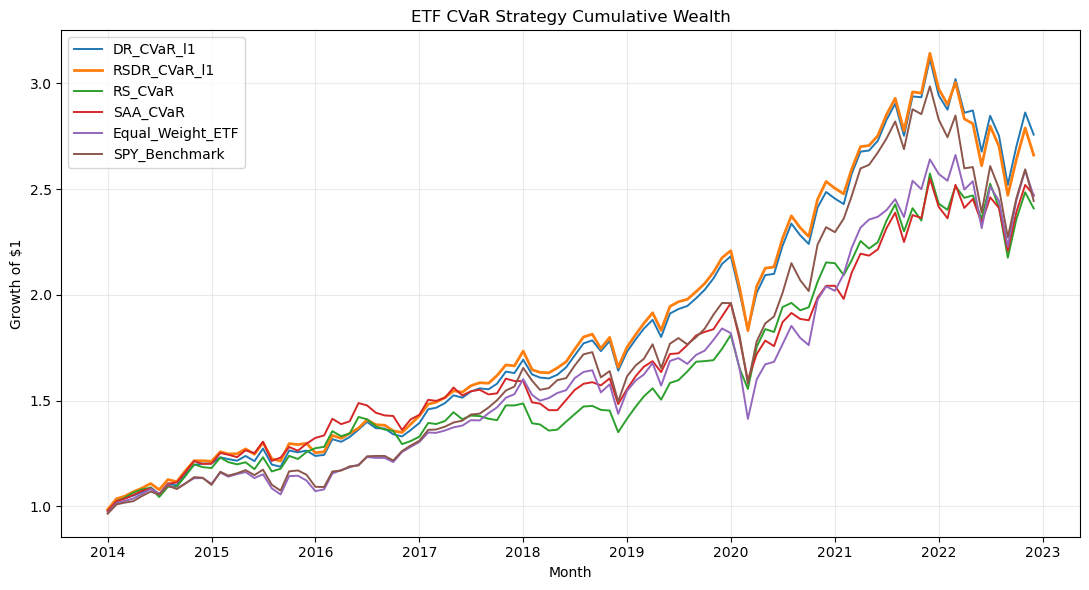

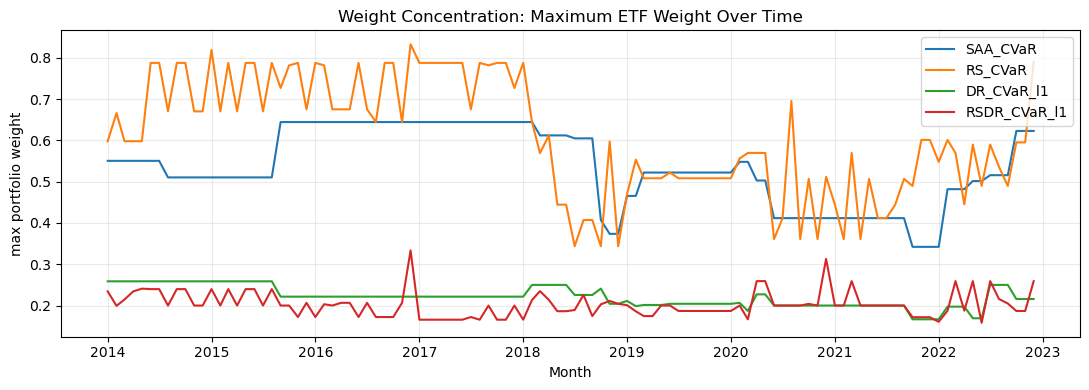

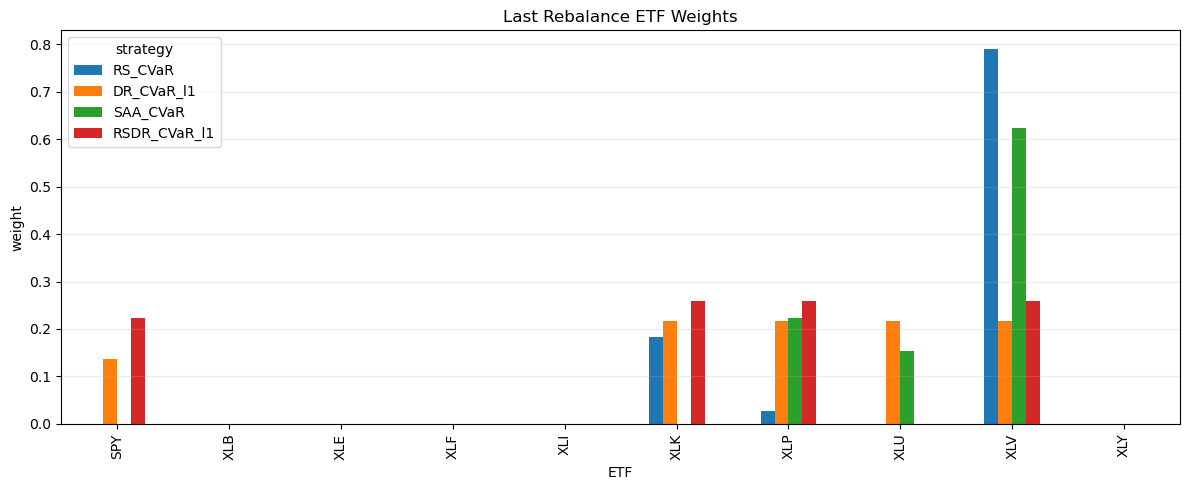

In [8]:
plt.figure(figsize=(11, 6))
wealth = (1.0 + returns_pivot).cumprod()
for col in wealth.columns:
    plt.plot(wealth.index, wealth[col], label=col, linewidth=2 if "RSDR" in col else 1.4)
plt.title("ETF CVaR Strategy Cumulative Wealth")
plt.ylabel("Growth of $1")
plt.xlabel("Month")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
for strategy in diagnostics["strategy"].unique():
    g = diagnostics[diagnostics["strategy"] == strategy].sort_values("rebalance_month")
    plt.plot(g["rebalance_month"], g["max_weight"], label=strategy)
plt.title("Weight Concentration: Maximum ETF Weight Over Time")
plt.ylabel("max portfolio weight")
plt.xlabel("Month")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

last_weights = strategy_weights.sort_values("rebalance_month").groupby("strategy").tail(1)
last_weights.set_index("strategy")[asset_cols].T.plot(kind="bar", figsize=(12, 5))
plt.title("Last Rebalance ETF Weights")
plt.ylabel("weight")
plt.xlabel("ETF")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

